# Global Wealth Inequality

For this project, I focus on **wealth inequality—measured primarily by the Top 10% wealth share—rather than the Gini coefficient**, because my objective is to examine long-term structural concentration and mobility in asset ownership. While the Gini provides a useful summary of overall inequality, it compresses distributional changes into a single index and is often less sensitive to shifts at the top of the distribution. In contrast, wealth shares—especially the Top 10% and Bottom 50%—more directly capture changes in asset concentration, elite accumulation, and post-COVID financial dynamics. Since wealth reflects accumulated assets, capital gains, and intergenerational transfers, it is a stronger indicator of structural inequality and long-run mobility than income-based summary measures. By focusing on wealth shares from 2020–2024, this analysis better captures how asset price shocks and financial market dynamics reshaped distributional outcomes across income groups.

I begin this project with the assumption that wealth inequality may be higher in lower- and middle-income countries due to structural factors such as volatile financial systems, weaker democratic institutions, and elite-dominated economic structures. At the same time, highly capitalized economies with relatively weak welfare systems may also exhibit elevated levels of wealth concentration. Rather than relying on these assumptions, this analysis examines cross-country data to identify whether systematic patterns emerge.

This project is guided by the following research questions:

* Are there observable patterns in global wealth inequality across income groups?
* Are there regional patterns in global wealth inequality?
* Has wealth inequality increased or decreased in the period 2020–2024?
* Does the magnitude of change differ by income group or region?

By addressing these questions, the study aims to understand whether recent shifts in wealth concentration reflect structural development levels, institutional differences, or broader global asset dynamics.

### Data Collection
- GNI per capita (https://data.worldbank.org/indicator/NY.GNP.PCAP.CD)
- World Inequality Database (https://wid.world/world/#sptinc_p90p100_z/US;FR;DE;CN;ZA;GB;WO-PPP/last/eu/k/p/yearly/s/false/24.708000000000002/80/curve/false/country)
- World Bank country classifications by income level for 2024-2025 (https://datahelpdesk.worldbank.org/knowledgebase/articles/378834-how-does-the-world-bank-classify-countries)

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        if 'top10' in file_path:
            top10_file_path = file_path
            print(f"top10 file: {top10_file_path}")
        elif 'bottom50' in file_path:
            bottom50_file_path = file_path
            print(f"bottom50 file: {bottom50_file_path}")
        elif 'gni' in file_path:
            gni_file_path = file_path
            print(f'gni file: {gni_file_path}')
        elif 'level' in file_path:
            level_file_path = file_path
            print(f'level file: {level_file_path}')
        else: 
            print('none exist')

level file: /kaggle/input/datasets/sungeun7/income-level/WB_income_level_2000-2024.xlsx
bottom50 file: /kaggle/input/datasets/sungeun7/wealth-bottom50/WID_wealth_bottom50.xlsx
top10 file: /kaggle/input/datasets/sungeun7/wealth-top10/WID_wealth_top10.xlsx
gni file: /kaggle/input/datasets/sungeun7/income-gni/WID_GNI.xlsx


In [3]:
bottom_df = pd.read_excel(bottom50_file_path)
top_df = pd.read_excel(top10_file_path)
gni_df = pd.read_excel(gni_file_path)
inc_df = pd.read_excel(level_file_path)

In [4]:
top_df.head()

,Country,Percentile,shweal_z_2000\nNet personal wealth\nTop 10% | share | adults | equal split\n2000,shweal_z_2001\nNet personal wealth\nTop 10% | share | adults | equal split\n2001,shweal_z_2002\nNet personal wealth\nTop 10% | share | adults | equal split\n2002,shweal_z_2003\nNet personal wealth\nTop 10% | share | adults | equal split\n2003,shweal_z_2004\nNet personal wealth\nTop 10% | share | adults | equal split\n2004,shweal_z_2005\nNet personal wealth\nTop 10% | share | adults | equal split\n2005,shweal_z_2006\nNet personal wealth\nTop 10% | share | adults | equal split\n2006,shweal_z_2007\nNet personal wealth\nTop 10% | share | adults | equal split\n2007,...,shweal_z_2015\nNet personal wealth\nTop 10% | share | adults | equal split\n2015,shweal_z_2016\nNet personal wealth\nTop 10% | share | adults | equal split\n2016,shweal_z_2017\nNet personal wealth\nTop 10% | share | adults | equal split\n2017,shweal_z_2018\nNet personal wealth\nTop 10% | share | adults | equal split\n2018,shweal_z_2019\nNet personal wealth\nTop 10% | share | adults | equal split\n2019,shweal_z_2020\nNet personal wealth\nTop 10% | share | adults | equal split\n2020,shweal_z_2021\nNet personal wealth\nTop 10% | share | adults | equal split\n2021,shweal_z_2022\nNet personal wealth\nTop 10% | share | adults | equal split\n2022,shweal_z_2023\nNet personal wealth\nTop 10% | share | adults | equal split\n2023,shweal_z_2024\nNet personal wealth\nTop 10% | share | adults | equal split\n2024
0,Afghanistan,p90p100,0.5834,0.5834,0.5833,0.5834,0.5831,0.5831,0.5834,0.5832,...,0.5802,0.5809,0.5817,0.5817,0.5816,0.5816,0.5817,0.5817,0.5816,0.5816
1,Albania,p90p100,0.5667,0.5673,0.5678,0.5679,0.5674,0.5670,0.5667,0.5651,...,0.5716,0.5740,0.5725,0.5708,0.5694,0.5693,0.5691,0.5697,0.5691,0.5691
2,Algeria,p90p100,0.5992,0.5992,0.5992,0.5994,0.5991,0.5994,0.5991,0.5962,...,0.6222,0.6222,0.6221,0.6231,0.6229,0.6233,0.6237,0.6236,0.6226,0.6220
3,Andorra,p90p100,0.5730,0.5712,0.5696,0.5700,0.5708,0.5719,0.5747,0.5750,...,0.5706,0.5713,0.5719,0.5717,0.5707,0.5702,0.5728,0.5735,0.5734,0.5734
4,Angola,p90p100,0.7126,0.7078,0.6923,0.6689,0.6559,0.6481,0.6400,0.6308,...,0.6754,0.7017,0.7087,0.7121,0.7121,0.7122,0.7120,0.7121,0.7121,0.7122


### Data Cleaning

In [5]:
# Clean the column names to get only years
import re

def extract_year(col_name):
    match = re.search(r'(\d{4})$', col_name)  # find 4 digits at the end
    if match:
        return match.group(1)
    else:
        return col_name.strip().lower()  # fallback if no year found

top_df.columns = [extract_year(col) for col in top_df.columns]
bottom_df.columns = [extract_year(col) for col in bottom_df.columns]

print(top_df.columns)
print(bottom_df.columns)

Index(['country', 'percentile', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='object')
Index(['country', 'percentile', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='object')


In [6]:
# Remove unnessesary column
top_df.drop(columns=['percentile'], inplace=True)
bottom_df.drop(columns=['percentile'], inplace=True)

In [7]:
top_df.head()

,country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,0.5834,0.5834,0.5833,0.5834,0.5831,0.5831,0.5834,0.5832,0.5833,...,0.5802,0.5809,0.5817,0.5817,0.5816,0.5816,0.5817,0.5817,0.5816,0.5816
1,Albania,0.5667,0.5673,0.5678,0.5679,0.5674,0.5670,0.5667,0.5651,0.5669,...,0.5716,0.5740,0.5725,0.5708,0.5694,0.5693,0.5691,0.5697,0.5691,0.5691
2,Algeria,0.5992,0.5992,0.5992,0.5994,0.5991,0.5994,0.5991,0.5962,0.5930,...,0.6222,0.6222,0.6221,0.6231,0.6229,0.6233,0.6237,0.6236,0.6226,0.6220
3,Andorra,0.5730,0.5712,0.5696,0.5700,0.5708,0.5719,0.5747,0.5750,0.5689,...,0.5706,0.5713,0.5719,0.5717,0.5707,0.5702,0.5728,0.5735,0.5734,0.5734
4,Angola,0.7126,0.7078,0.6923,0.6689,0.6559,0.6481,0.6400,0.6308,0.6234,...,0.6754,0.7017,0.7087,0.7121,0.7121,0.7122,0.7120,0.7121,0.7121,0.7122


In [8]:
# remove leading and training spaces from the country column
top_df['country'] = top_df['country'].str.strip()
bottom_df['country'] = bottom_df['country'].str.strip()

# A. Cross-Sectional Analysis of Wealth Inequality (2024)
This section provides a global snapshot of wealth distribution as of 2024. By analyzing the concentration of assets in the Top 10% versus the Bottom 50%, we can identify structural disparities across different economic regimes.

## A.1 Top 10% Share of Wealth
> Top 10% Share of Wealth = The percentage of total national wealth held by the richest 10% of adults in a country.

* It is ranked by net wealth (assets minus liabilities). Includes all forms of wealth: property, stocks, businesses, savings, minus debts.

---
* **High value (70–90%)** → wealth is highly concentrated among a few.
* **Moderate value (40–60%)** → more even distribution, though still unequal.
* **Low value (<40%)** → very evenly distributed wealth (rare globally).

In [9]:
top_2024 = top_df[['country','2024']]
bottom_2024 = bottom_df[['country','2024']] 

#### 10 countries with the highest top 10% wealth share 

In [10]:
top_2024.sort_values('2024', ascending=False)[:10]

,country,2024
181,South Africa,0.8567
209,Uruguay,0.7671
162,Russian Federation,0.7603
187,Swaziland,0.7448
91,Iraq,0.7292
136,Namibia,0.7256
126,Mexico,0.7205
40,Chile,0.7200
26,Botswana,0.7197
42,Colombia,0.7191


**The highest top 10% wealth shares are concentrated in upper-middle-income countries, particularly in Southern Africa and Latin America(8 out of 10).** Many of these economies are characterized by colonial land concentration histories, resource dependence, and weaker redistributive institutions. This suggests that structural and institutional factors, rather than income level alone, shape extreme wealth concentration.

#### 10 countries with the lowest top 10% wealth share

In [11]:
top_2024.sort_values('2024')[:10]

,country,2024
139,Netherlands,0.4553
177,Slovakia,0.4940
53,Denmark,0.5026
18,Belgium,0.5260
147,Norway,0.5270
122,Malta,0.5400
65,Finland,0.5551
95,Italy,0.5612
146,North Macedonia,0.5631
17,Belarus,0.5645


**The lowest top 10% wealth shares are concentrated in European countries(9 out of 10), particularly Nordic and Western European economies.** This pattern suggests that institutional factors such as welfare state strength, labor market coordination, and financial regulation may play a more important role than income level in shaping wealth concentration.


## A.2 Bottom 50% Share of Wealth

> Bottom 50% Share of Wealth = The proportion of total national wealth held by the poorest 50% of adults in a country.

* “Bottom 50%” means the poorest half of the population (by wealth, not income). It looks at ownership of assets, not earnings.

---
* **0%** → The bottom half owns almost nothing. Wealth is extremely concentrated at the top.
* **10%** → The bottom 50% owns just 10% of all wealth. Still very unequal.
* **50%** → Perfect equality (very rare). The bottom half owns as much as the top half.
---
**Why it can be negative:**
* Remember: Wealth = Assets - Liabilities (debt)
* Some people, especially in the bottom half, may have more debt than assets.
* Example: student loans, mortgages, credit card debt.
* **Bottom 50% Share < 0** → Bottom half of adults are **net in debt overall**.

Real-world examples:
* Some European countries after the 2008 crisis had slightly negative bottom 50% shares because mortgages exceeded housing value for many households.
* In the US, for some years, studies show the bottom 50% collectively have negative net wealth.

#### 10 countries with the lowest bottom 50% share of wealth

In [12]:
# negatives ascending (more negative first)
# positives descending
negatives = bottom_2024[bottom_2024['2024'] < 0].sort_values(by='2024')
positives = bottom_2024[bottom_2024['2024'] >= 0].sort_values(by='2024', ascending=False)

bottom_2024_sorted = pd.concat([negatives, positives])

bottom_2024_sorted.head(10)

,country,2024
188,Sweden,-0.1087
92,Ireland,-0.0342
181,South Africa,-0.0247
75,Greece,-0.0183
157,Poland,-0.0075
36,Canada,0.1398
122,Malta,0.1034
139,Netherlands,0.0979
177,Slovakia,0.0744
18,Belgium,0.0740


Most of the countries with the lowest bottom 50% wealth shares are advanced, highly financialized economies with high levels of household debt. A negative wealth share means that the bottom half of the population holds more debt than assets, which often occurs in mortgage-heavy housing systems, student loan–based education financing, and credit-driven consumption economies. The case of Sweden is particularly striking: despite its strong welfare state, the bottom 50% shows the most negative wealth share, reflecting very high household indebtedness. This suggests that financialization and debt structures may matter more than welfare generosity in shaping wealth outcomes at the bottom of the distribution.


#### 10 countries with the highest bottom 50% share of wealth

In [13]:
bottom_2024_sorted.tail(10)

,country,2024
126,Mexico,0.0203
40,Chile,0.0201
42,Colombia,0.0199
26,Botswana,0.0197
187,Swaziland,0.0182
136,Namibia,0.0182
91,Iraq,0.0173
103,Korea,0.0172
62,Estonia,0.0109
204,USA,0.0096


Many of the countries with the highest bottom 50% wealth shares are upper-middle-income or emerging economies with lower levels of household debt and less developed credit markets. In these contexts, poorer households may own very little wealth, but they also tend to have limited access to formal borrowing, such as mortgages, consumer loans, or student debt. As a result, while their asset base is small, their liabilities are also relatively low, leading to slightly positive net wealth shares for the bottom half of the population. This suggests that a higher bottom 50% wealth share in these countries may reflect lower indebtedness rather than genuinely broad-based wealth accumulation.

#### Key findings:
This suggests two different mechanisms in wealth concentration:

**1. Elite concentration:** In some middle-income, resource-dependent, or historically unequal countries, wealth is heavily concentrated at the top due to structural and historical asset ownership patterns.

**2. Household indebtedness:** In highly financialized advanced economies, high levels of household debt can push the bottom 50% into negative net wealth, deepening measured inequality from below.



## A.3 Structural Groupings: 
- Comparing outcomes across Nordic, Financialized, and Emerging market models.

I group countries into highly financialized economies, Nordic model economies, and emerging markets to capture structural differences in how wealth is accumulated and distributed. Highly financialized economies (e.g., United States, United Kingdom) tend to have deep capital markets and high stock ownership concentration, making top wealth shares more responsive to asset price shocks. Nordic model economies (e.g., Sweden, Norway) combine advanced markets with strong redistributive institutions, allowing comparison between market-driven concentration and welfare-state mitigation. Emerging markets (e.g., China, Brazil) differ in financial depth, asset composition, and structural development, offering insight into how wealth concentration evolves in rapidly changing economies.

In [14]:
nordic = ['Sweden','Norway','Denmark','Finland']
nordic_df = top_2024[top_2024['country'].isin(nordic)]
print('range:',round(min(nordic_df['2024']),2),'-',round(max(nordic_df['2024']),2))
nordic_df

range: 0.5 - 0.68


,country,2024
53,Denmark,0.5026
65,Finland,0.5551
147,Norway,0.5270
188,Sweden,0.6822


In [15]:
financialized = ['USA','United Kingdom','Canada','Australia']
finan_df = top_2024[top_2024['country'].isin(financialized)]
print('range:',round(min(finan_df['2024']),2),'-',round(max(finan_df['2024']),2))
finan_df

range: 0.57 - 0.7


,country,2024
10,Australia,0.5770
36,Canada,0.5979
204,USA,0.6954
208,United Kingdom,0.5714


In [16]:
emerging = ['China','Brazil','South Africa']
emerging_df = top_2024[top_2024['country'].isin(emerging)]
print('range:',round(min(emerging_df['2024']),2),'-',round(max(emerging_df['2024']),2))
emerging_df

range: 0.68 - 0.86


,country,2024
27,Brazil,0.7190
41,China,0.6805
181,South Africa,0.8567


#### Key findings:
| Country                             | Top 10% Share of Wealth |
| ----------------------------------- | ----------------------- |
| Highly Financialized Economies      | ~57–70%                 |
| Nordic countries                    | ~50–68%                 |
| Emerging Asset-Growth Economies     | ~68—86%                    |

In most developed economies, the **top 10% owns more than half of all wealth**, showing extreme concentration.
The table suggests that wealth concentration varies systematically by economic structure rather than income level alone. **Highly financialized economies** show top 10% wealth shares of roughly 57–70%, indicating substantial concentration driven by capital markets, housing assets, and financial wealth. **Emerging asset-growth economies** display even higher concentration (about 68–86%), suggesting that rapid capital accumulation, resource dependence, or elite asset ownership can intensify wealth inequality at the top. In contrast, **Nordic countries** fall in a comparatively lower range (around 50–68%), consistent with stronger redistributive institutions, coordinated labor markets, and more equal asset distribution.

Overall, the pattern implies that institutional structure and financial systems may play a more decisive role in shaping top-end wealth concentration than development level alone.


## A.4 Income Level Analysis
- Summary statistics and ANOVA tests examining differences in wealth distribution across World Bank income classifications (High, Upper-Middle, Lower-Middle, and Low income).

In [17]:
pip install country_converter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [18]:
import country_converter as coco

top_df2 = top_df
bottom_df2 = bottom_df

# Convert datasets to standard short names
inc_df['country_std'] = coco.convert(names=inc_df['country'], to='name_short')
top_df2['country_std'] = coco.convert(names=top_df2['country'], to='name_short')
bottom_df2['country_std'] = coco.convert(names=bottom_df2['country'], to='name_short')

# Now compare 
set(inc_df['country_std']) == set(top_df2['country_std'])
print(set(inc_df['country_std']) - set(top_df2['country_std']))
print(set(top_df2['country_std']) - set(inc_df['country_std']))

inc_df.columns = inc_df.columns.map(str)
inc_df = inc_df.rename(columns={'2024': 'income_group'})

top_df2 = top_df2.rename(
    columns={col: f"top10_{col}" for col in top_df2.columns if col.isdigit()})
bottom_df2 = bottom_df2.rename(
    columns={col: f"bottom50_{col}" for col in bottom_df2.columns if col.isdigit()})

merged_t = top_df2.merge(inc_df[['country_std','income_group']], on='country_std')
merged = merged_t.merge(bottom_df2, on='country_std')

print(merged.shape)
merged.head()

Channel Islands not found in regex
German Democratic Republic not found in regex
German Democratic Republic not found in regex


{'American Samoa', 'United States Virgin Islands', 'Faroe Islands', 'Northern Mariana Islands', 'Guam', 'Saint-Martin'}
{'Bonaire, Saint Eustatius and Saba', 'Anguilla', 'Jersey', 'Montserrat', 'Guernsey'}
(212, 54)


,country_x,top10_2000,top10_2001,top10_2002,top10_2003,top10_2004,top10_2005,top10_2006,top10_2007,top10_2008,...,bottom50_2015,bottom50_2016,bottom50_2017,bottom50_2018,bottom50_2019,bottom50_2020,bottom50_2021,bottom50_2022,bottom50_2023,bottom50_2024
0,Afghanistan,0.5834,0.5834,0.5833,0.5834,0.5831,0.5831,0.5834,0.5832,0.5833,...,0.0480,0.0479,0.0478,0.0478,0.0478,0.0478,0.0478,0.0478,0.0478,0.0478
1,Albania,0.5667,0.5673,0.5678,0.5679,0.5674,0.5670,0.5667,0.5651,0.5669,...,0.0494,0.0490,0.0492,0.0495,0.0497,0.0497,0.0498,0.0497,0.0498,0.0498
2,Algeria,0.5992,0.5992,0.5992,0.5994,0.5991,0.5994,0.5991,0.5962,0.5930,...,0.0408,0.0408,0.0408,0.0407,0.0407,0.0407,0.0406,0.0406,0.0407,0.0408
3,Andorra,0.5730,0.5712,0.5696,0.5700,0.5708,0.5719,0.5747,0.5750,0.5689,...,0.0495,0.0494,0.0493,0.0494,0.0495,0.0496,0.0492,0.0491,0.0491,0.0491
4,Angola,0.7126,0.7078,0.6923,0.6689,0.6559,0.6481,0.6400,0.6308,0.6234,...,0.0302,0.0242,0.0225,0.0217,0.0216,0.0216,0.0217,0.0217,0.0216,0.0216


#### Summary stattistics of Top 10% wealth share by income level

In [19]:
# convert to percentage points
merged['top10_2024_pp'] = merged['top10_2024'] * 100

summary = (
    merged
    .groupby('income_group', observed=False)
    .agg(
        num_countries=('top10_2024_pp','count'),
        mean_top10share_pp=('top10_2024_pp', 'mean'),
        median_top10share_pp=('top10_2024_pp', 'median'),
        std_top10share_pp=('top10_2024_pp', 'std'),
        min_top10share_pp=('top10_2024_pp', 'min'),
        max_top10share_pp=('top10_2024_pp', 'max')
    )
    .reset_index()
    .sort_values('income_group')
    .round(2)
)

summary

,income_group,num_countries,mean_top10share_pp,median_top10share_pp,std_top10share_pp,min_top10share_pp,max_top10share_pp
0,H,80,61.24,61.64,5.35,45.53,76.71
1,L,26,61.72,60.35,3.81,58.14,71.65
2,LM,50,62.42,61.60,4.06,57.71,74.48
3,UM,54,62.51,61.54,5.56,56.31,85.67


**Across all income levels, the richest 10% own roughly 60%+ of total wealth.**
- There is no meaningful gradient from low → high income countries.
- Upper-middle income countries show the widest dispersion.
- Low income countries appear more clustered.


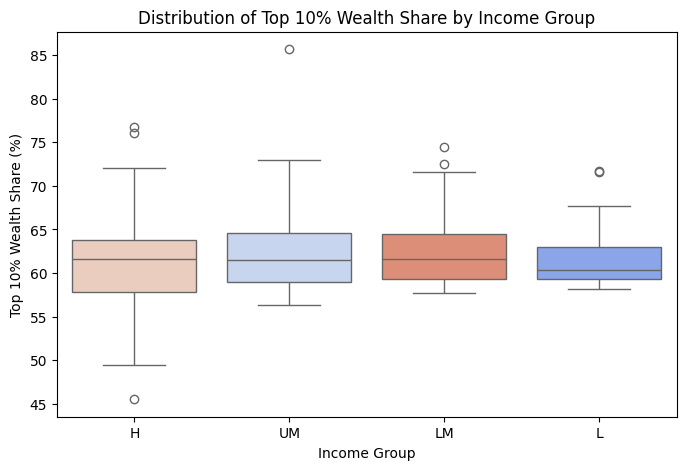

In [44]:
# Specify the order explicitly
order = ['H', 'UM', 'LM', 'L']

plt.figure(figsize=(8,5))
sns.boxplot(
    data=merged,
    x='income_group',
    y='top10_2024_pp',
    hue='income_group',        # explicitly assign hue
    palette='coolwarm',
    order=order,
    dodge=False                # keep boxes together
)
plt.legend([],[], frameon=False)  # hide legend
plt.ylabel("Top 10% Wealth Share (%)")
plt.xlabel("Income Group")
plt.title("Distribution of Top 10% Wealth Share by Income Group")
plt.show()

In [21]:
# Test Whether Mean Changes Differ Across Groups: Use ANOVA (difference in group means)
from scipy import stats

groups_data = [
    group['top10_2024_pp'].dropna().values
    for name, group in merged.groupby('income_group')
    if len(group['top10_2024_pp'].dropna()) > 1  # avoid groups with 1 obs
]

f_stat, p_value = stats.f_oneway(*groups_data)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 0.938
P-value: 0.4231


##### Results:
Descriptive statistics indicate that the top 10% wealth share averages between 61–63% across all World Bank income groups. The similarity in both means and medians suggests that wealth concentration is structurally high regardless of national income classification. Combined with a non-significant ANOVA result, this implies that income level alone does not meaningfully differentiate levels of wealth concentration.

#### Summary stattistics of Bottom 50% wealth share by income level

In [22]:
# convert to percentage points
merged['bottom50_2024_pp'] = merged['bottom50_2024'] * 100

summary = (
    merged
    .groupby('income_group', observed=False)
    .agg(
        num_countries=('bottom50_2024_pp','count'),
        mean_bottom50share_pp=('bottom50_2024_pp', 'mean'),
        median_bottom50share_pp=('bottom50_2024_pp', 'median'),
        std_bottom50share_pp=('bottom50_2024_pp', 'std'),
        min_bottom50share_pp=('bottom50_2024_pp', 'min'),
        max_bottom50share_pp=('bottom50_2024_pp', 'max')
    )
    .reset_index()
    .sort_values('income_group')
    .round(2)
)

summary

,income_group,num_countries,mean_bottom50share_pp,median_bottom50share_pp,std_bottom50share_pp,min_bottom50share_pp,max_bottom50share_pp
0,H,80,3.92,4.12,2.77,-10.87,13.98
1,L,26,4.13,4.41,0.76,2.06,4.78
2,LM,50,4.07,4.22,0.86,1.82,6.42
3,UM,54,3.97,4.20,1.31,-2.47,6.32


**The bottom 50% of the population owns only about 4% of total wealth, regardless of income level.**

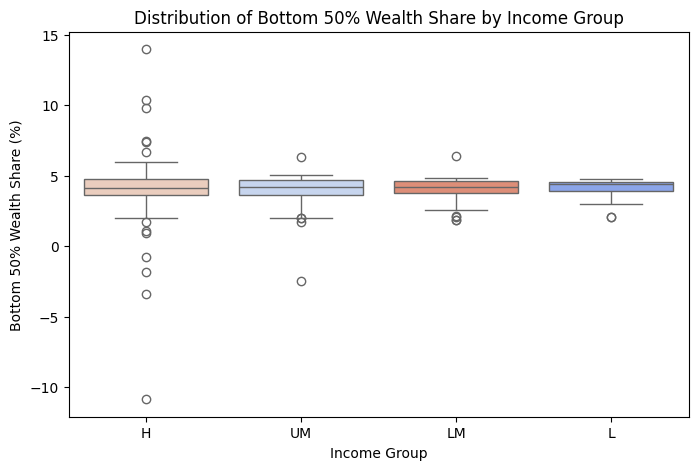

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=merged,
    x='income_group',
    y='bottom50_2024_pp',
    hue='income_group',        # explicitly assign hue
    palette='coolwarm',
    order=order,
    dodge=False                # keep boxes together
)
plt.legend([],[], frameon=False)  # hide legend
plt.ylabel("Bottom 50% Wealth Share (%)")
plt.xlabel("Income Group")
plt.title("Distribution of Bottom 50% Wealth Share by Income Group")
plt.show()

In [23]:
groups_data = [
    group['bottom50_2024_pp'].dropna().values
    for name, group in merged.groupby('income_group')
    if len(group['bottom50_2024_pp'].dropna()) > 1  # avoid groups with 1 obs
]

f_stat, p_value = stats.f_oneway(*groups_data)

print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 0.108
P-value: 0.9555


##### Results:
Descriptive statistics show that the bottom 50% holds approximately 4% of national wealth across all income groups. A one-way ANOVA confirms that differences across income classifications are statistically insignificant (F = 0.11, p = 0.96). This suggests that wealth exclusion at the bottom is structurally persistent and not strongly associated with national income level.

#### Key Findings: 

##### Wealth Exclusion Is Structurally Persistent

* The **bottom 50% holds ~4% of total wealth** across all income groups.
* The **top 10% controls ~60–63% of total wealth**.
* ANOVA results show **no statistically significant differences** across World Bank income classifications.
* Wealth concentration is therefore **not systematically related to income level**.

##### Negative Wealth Shares

* In some high- and upper-middle-income countries, the bottom 50% wealth share is **negative** (debts exceed assets).
* This pattern is most common in **highly financialized economies** with high household debt and deep credit markets.
* Low-income countries do not show negative shares, likely due to **limited access to formal credit**.

##### Overall Interpretation

* Wealth inequality appears **globally persistent and structurally embedded**.
* Contrary to the initial expectation, poorer countries do **not** systematically exhibit higher wealth inequality.
* Income classification alone does **not** meaningfully explain differences in wealth concentration.


## A.5 Correlation with GNI per Capita

Regression analysis examining whether national income level is systematically associated with wealth inequality.

* **Independent variable (X):** GNI per capita
* **Dependent variable (Y):** Top 10% wealth share or Bottom 50% wealth share

This analysis tests whether poorer countries inherently exhibit higher wealth concentration.

In [24]:
gni_df.head() 

,Country,Percentile,anninc_992_i_2000\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2000,anninc_992_i_2001\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2001,anninc_992_i_2002\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2002,anninc_992_i_2003\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2003,anninc_992_i_2004\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2004,anninc_992_i_2005\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2005,anninc_992_i_2006\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2006,anninc_992_i_2007\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2007,...,anninc_992_i_2015\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2015,anninc_992_i_2016\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2016,anninc_992_i_2017\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2017,anninc_992_i_2018\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2018,anninc_992_i_2019\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2019,anninc_992_i_2020\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2020,anninc_992_i_2021\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2021,anninc_992_i_2022\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2022,anninc_992_i_2023\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2023,anninc_992_i_2024\nNational income\nTotal population | average income or wealth | adults | individual | | ppp | constant (2024)\n2024
0,Afghanistan,pall,2345.4933,2185.1640,3087.8042,3483.1912,3427.1223,3541.1125,3680.1901,4456.1001,...,4665.3154,4578.3504,4509.4458,4408.1754,4680.5722,4487.3233,3538.5857,3015.0036,3098.3747,3395.4611
1,Albania,pall,7719.9121,8467.3093,8703.7259,9137.1846,9462.3777,9923.4210,10639.6157,11203.3811,...,13398.6842,13906.7916,14031.9703,14393.5961,14405.9837,13792.1596,14897.2466,15700.4744,16423.9097,17339.3485
2,Algeria,pall,13111.1073,12912.5746,13209.6571,13658.3415,13728.7496,14139.5023,14179.2763,14587.8950,...,14636.0783,15153.2159,14929.0592,14794.0823,14681.1351,13690.2058,14080.9549,14300.8484,14876.7886,14890.2031
3,Andorra,pall,54930.5804,57623.6801,57659.1171,58156.1293,57254.3305,57350.8040,57826.9118,57031.6475,...,52803.1312,54268.7918,53488.1718,52775.7430,56420.4991,50008.0803,50522.6433,52510.2450,53017.7653,54406.4036
4,Angola,pall,7926.2057,7901.9792,9120.6192,9067.0324,9536.3960,10623.9555,11205.6308,12298.2406,...,14251.5547,13342.1574,12798.1534,12026.8904,11383.3778,10312.1869,10338.1343,10543.9406,9892.7031,10252.2623


In [25]:
# Clean the column 
import re

def extract_year(col_name):
    match = re.search(r'(\d{4})$', col_name)  # find 4 digits at the end
    if match:
        return match.group(1)
    else:
        return col_name.strip().lower()  # fallback if no year found

gni_df.columns = [extract_year(col) for col in gni_df.columns]
print(gni_df.columns)

# remove leading and training spaces from the country column
gni_df['country'] = gni_df['country'].str.strip()
gni_df.drop(columns='percentile', inplace=True)

gni_df.head()

Index(['country', 'percentile', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='object')


,country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,2345.4933,2185.1640,3087.8042,3483.1912,3427.1223,3541.1125,3680.1901,4456.1001,4238.5340,...,4665.3154,4578.3504,4509.4458,4408.1754,4680.5722,4487.3233,3538.5857,3015.0036,3098.3747,3395.4611
1,Albania,7719.9121,8467.3093,8703.7259,9137.1846,9462.3777,9923.4210,10639.6157,11203.3811,11664.3381,...,13398.6842,13906.7916,14031.9703,14393.5961,14405.9837,13792.1596,14897.2466,15700.4744,16423.9097,17339.3485
2,Algeria,13111.1073,12912.5746,13209.6571,13658.3415,13728.7496,14139.5023,14179.2763,14587.8950,14700.5917,...,14636.0783,15153.2159,14929.0592,14794.0823,14681.1351,13690.2058,14080.9549,14300.8484,14876.7886,14890.2031
3,Andorra,54930.5804,57623.6801,57659.1171,58156.1293,57254.3305,57350.8040,57826.9118,57031.6475,53312.7755,...,52803.1312,54268.7918,53488.1718,52775.7430,56420.4991,50008.0803,50522.6433,52510.2450,53017.7653,54406.4036
4,Angola,7926.2057,7901.9792,9120.6192,9067.0324,9536.3960,10623.9555,11205.6308,12298.2406,12612.0799,...,14251.5547,13342.1574,12798.1534,12026.8904,11383.3778,10312.1869,10338.1343,10543.9406,9892.7031,10252.2623


In [26]:
# Relation of top 10 share of wealth and GNI
import statsmodels.api as sm

# Merge data
df_gni_top = top_df[['country','2024']].merge(
    gni_df[['country','2024']],
    on='country',
    suffixes=('_top10','_gni')
)
# rename columns
df_gni_top = df_gni_top.rename(columns={
    '2024_top10': 'top10_share',
    '2024_gni': 'gni_per_capita'
})
# Take log of GNI
df_gni_top['log_gni'] = np.log(df_gni_top['gni_per_capita'])

# Drop missing values
df_gni_top = df_gni_top.dropna()

# Run regression
X = sm.add_constant(df_gni_top['log_gni'])  # add intercept
y = df_gni_top['top10_share']

model_top = sm.OLS(y, X).fit()

print(model_top.summary())

                            OLS Regression Results                            
Dep. Variable:            top10_share   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     3.502
Date:                Wed, 04 Mar 2026   Prob (F-statistic):             0.0627
Time:                        22:02:01   Log-Likelihood:                 346.57
No. Observations:                 216   AIC:                            -689.1
Df Residuals:                     214   BIC:                            -682.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6753      0.030     22.235      0.0

In [27]:
# Relation of bottom 50 share of wealth and GNI
import statsmodels.api as sm

# Merge data
df_gni_bottom = bottom_df[['country','2024']].merge(
    gni_df[['country','2024']],
    on='country',
    suffixes=('_bottom50','_gni')
)
# rename columns
df_gni_bottom = df_gni_bottom.rename(columns={
    '2024_bottom50': 'bottom50_share',
    '2024_gni': 'gni_per_capita'
})
# Take log of GNI
df_gni_bottom['log_gni'] = np.log(df_gni_bottom['gni_per_capita'])

# Drop missing values
df_gni_bottom = df_gni_bottom.dropna()

# Run regression
X = sm.add_constant(df_gni_bottom['log_gni'])  # add intercept
y = df_gni_bottom['bottom50_share']

model_bottom = sm.OLS(y, X).fit()

print(model_bottom.summary())

                            OLS Regression Results                            
Dep. Variable:         bottom50_share   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                   0.01162
Date:                Wed, 04 Mar 2026   Prob (F-statistic):              0.914
Time:                        22:02:01   Log-Likelihood:                 553.91
No. Observations:                 216   AIC:                            -1104.
Df Residuals:                     214   BIC:                            -1097.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0413      0.012      3.550      0.0

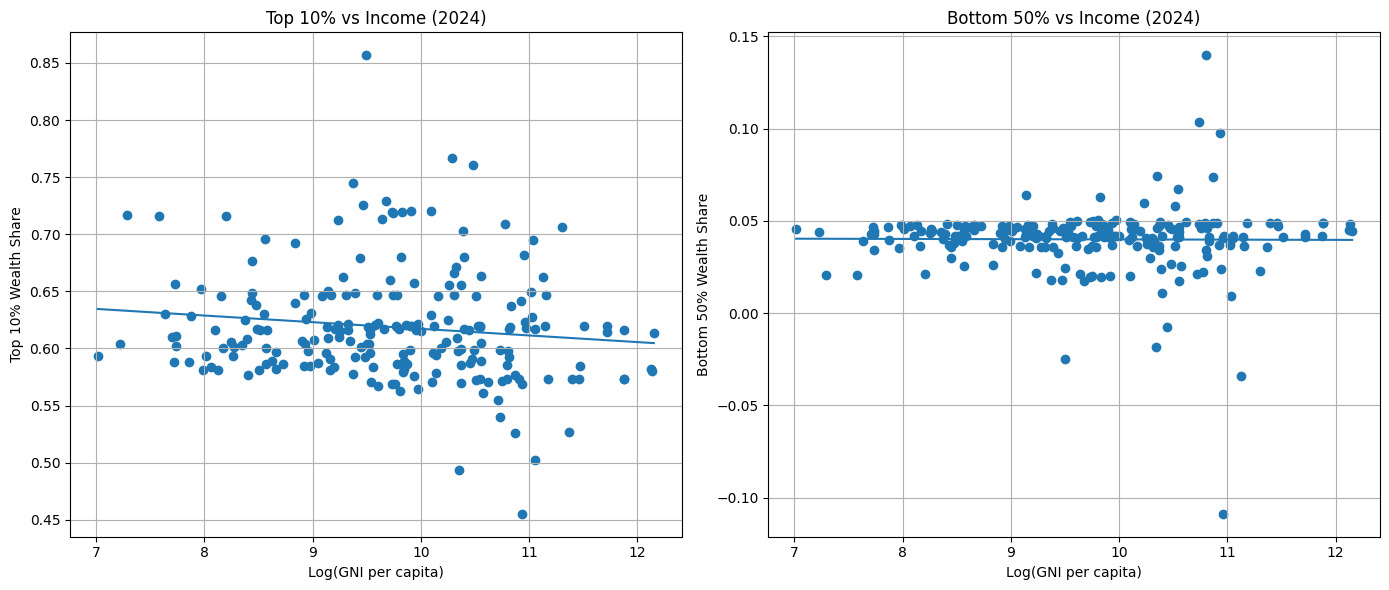

In [28]:
# Plot the result
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# ---------- LEFT: Top 10% ----------
axes[0].scatter(df_gni_top['log_gni'], df_gni_top['top10_share'])
# Regression line (top)
x_top = np.linspace(df_gni_top['log_gni'].min(),
                    df_gni_top['log_gni'].max(), 100)
y_top = model_top.params['const'] + model_top.params['log_gni'] * x_top
axes[0].plot(x_top, y_top)
axes[0].set_xlabel('Log(GNI per capita)')
axes[0].set_ylabel('Top 10% Wealth Share')
axes[0].set_title('Top 10% vs Income (2024)')
axes[0].grid(True)

# ---------- RIGHT: Bottom 50% ----------
axes[1].scatter(df_gni_bottom['log_gni'], df_gni_bottom['bottom50_share'])
# Regression line (bottom)
x_bottom = np.linspace(df_gni_bottom['log_gni'].min(),
                       df_gni_bottom['log_gni'].max(), 100)
y_bottom = model_bottom.params['const'] + model_bottom.params['log_gni'] * x_bottom
axes[1].plot(x_bottom, y_bottom)
axes[1].set_xlabel('Log(GNI per capita)')
axes[1].set_ylabel('Bottom 50% Wealth Share')
axes[1].set_title('Bottom 50% vs Income (2024)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Key Findings:
- There is weak evidence that richer countries may have slightly lower top 10% concentration, but the effect is small and statistically fragile.
- There is no relationship whatsoever between national income level and the bottom 50% wealth share.
- This reinforces your earlier finding: **Wealth inequality appears structurally persistent and not primarily determined by development level.**

# B. Time Trend Analysis (2000–2024)
Examines how wealth concentration has evolved over the past two decades, with particular attention to developments after 2020.

## B.1 Global Average Changes 
Compares mean wealth shares in 2000 and 2024 to assess whether global wealth inequality has structurally changed or remained persistent over time.

In [29]:
# Check the change of top 10% wealth share
summary_table = top_df2[['top10_2000','top10_2024']].mean().to_frame().T
summary_table

,top10_2000,top10_2024
0,0.624641,0.618824


In [30]:
# Check the change of bottom 50% wealth share
summary_table = bottom_df2[['bottom50_2000','bottom50_2024']].mean().to_frame().T
summary_table

,bottom50_2000,bottom50_2024
0,0.039744,0.040041


#### Key Findings:
**On average, global wealth concentration has remained structurally persistent since 2000.**

## B.2 Longitudinal Trends for Key Economies 
Visualizing the paths of major players (USA, China, Brazil, etc.) using line plots.

In [31]:
# check if the names correctly matche with ones in data
country_list = ['USA','China','India','United Kingdom'
             ,'Norway','Brazil','South Africa']

present = [c for c in country_list if c in top_df['country'].values]
missing = [c for c in country_list if c not in top_df['country'].values]
print("Present:", present)
print("Missing:", missing)

# selected countries
selected_top = top_df[top_df['country'].isin(country_list)].drop(columns='country_std')
selected_bottom = bottom_df[bottom_df['country'].isin(country_list)].drop(columns='country_std')
selected_top.head()

Present: ['USA', 'China', 'India', 'United Kingdom', 'Norway', 'Brazil', 'South Africa']
Missing: []


,country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
27,Brazil,0.7150,0.7148,0.7176,0.7160,0.7138,0.7205,0.7198,0.7158,0.7142,...,0.7167,0.7140,0.7130,0.7107,0.7078,0.7163,0.7236,0.7189,0.7166,0.7190
41,China,0.4775,0.4844,0.4901,0.4903,0.5061,0.5229,0.5393,0.5582,0.5691,...,0.6741,0.6741,0.6782,0.6772,0.6765,0.6795,0.6817,0.6805,0.6805,0.6805
88,India,0.5410,0.5534,0.5715,0.5694,0.5789,0.5820,0.5968,0.6206,0.6313,...,0.6415,0.6378,0.6435,0.6340,0.6292,0.6215,0.6437,0.6501,0.6502,0.6501
147,Norway,0.5120,0.5086,0.5091,0.5100,0.5130,0.5278,0.5144,0.5146,0.5156,...,0.4906,0.4918,0.5007,0.5114,0.5303,0.5252,0.5286,0.5299,0.5260,0.5270
181,South Africa,0.8365,0.8304,0.8263,0.8247,0.8172,0.8312,0.8517,0.8835,0.9083,...,0.8692,0.8676,0.8556,0.8555,0.8555,0.8556,0.8556,0.8555,0.8556,0.8567


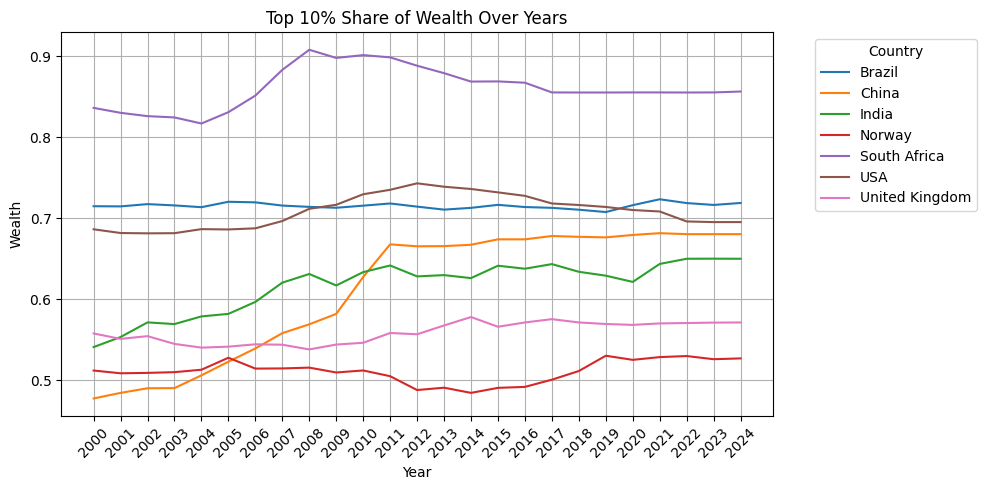

In [32]:
# Top 10% Share of Wealth Over Years

# Melt the dataframe to long format
df_tp_long = selected_top.melt(id_vars='country', var_name='year', value_name='wealth')

plt.figure(figsize=(10,5))
sns.lineplot(data=df_tp_long, x='year', y='wealth', hue='country',)
plt.title('Top 10% Share of Wealth Over Years')
plt.xlabel('Year')
plt.ylabel('Wealth')
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

* **South Africa** consistently has the highest concentration of wealth in the top 10% (~0.83–0.91). Wealth inequality is clearly extreme here.
* **USA** shows a noticeable increase from ~0.69 in 2000 to a peak around 2012 (~0.74), then a slight decline to ~0.70 by 2024.
* **China** shows a steady rise from ~0.47 in 2000 to ~0.68 in 2024, reflecting rapid accumulation of wealth by the top 10% during its economic growth.
* **India** gradually increases from ~0.55 to ~0.65, indicating growing wealth concentration.
* **Brazil, United Kingdom, and Norway** show relatively stable top 10% shares (~0.71 for Brazil, ~0.57 for UK, ~0.50 for Norway), with minor fluctuations. Norway is the most egalitarian among these.

**Overall trend:** Wealth is becoming increasingly concentrated in the top 10% in emerging economies like China and India, while advanced economies show moderate fluctuations, with South Africa remaining the most unequal.

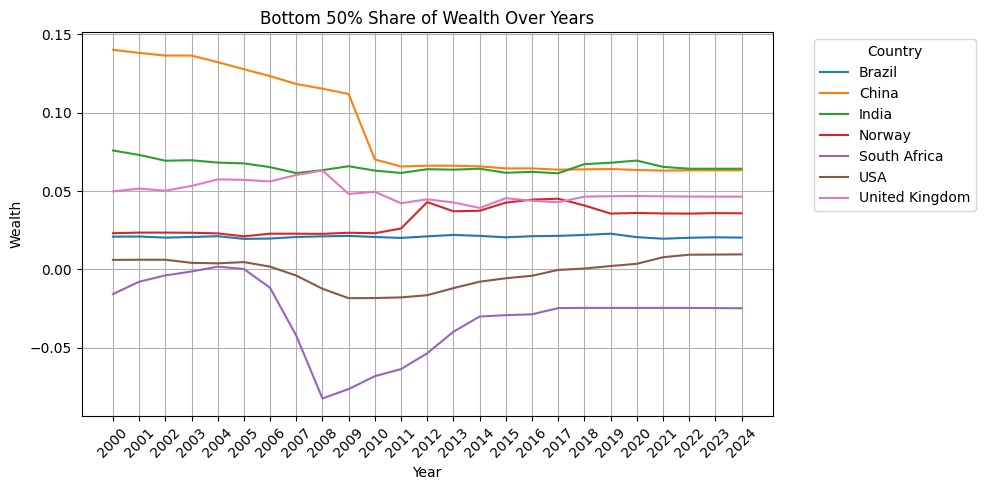

In [33]:
# Bottom 50% Share of Wealth Over Years

# Melt the dataframe to long format
df_bt_long = selected_bottom.melt(id_vars='country', var_name='year', value_name='wealth')

plt.figure(figsize=(10,5))
sns.lineplot(data=df_bt_long, x='year', y='wealth', hue='country',)
plt.title('Bottom 50% Share of Wealth Over Years')
plt.xlabel('Year')
plt.ylabel('Wealth')
plt.xticks(rotation=45)

plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

* **South Africa** shows negative wealth for the bottom 50% after 2006 (~–0.08), indicating that the poorest half are heavily indebted.
* **China** drops sharply around 2008–2011 from ~0.14 to ~0.07, then stabilizes, mirroring the rapid concentration of wealth in the top 10%.
* **USA** starts slightly negative around –0.02 in 2008, but recovers gradually to ~0.01 by 2024.
* **India** stays relatively stable (~0.06), indicating moderate wealth distribution among the bottom 50%.
* **Brazil, Norway, and UK** remain stable (~0.02–0.05), suggesting the bottom half retains a small but positive share.

**Overall trend:** The bottom 50% is losing relative wealth in countries experiencing rapid top-end accumulation (China, USA, South Africa). South Africa shows the most extreme bottom 50% impoverishment.


#### **Key Findings:**

1. **High inequality:** South Africa > USA > China/India > Brazil/UK/Norway.
2. **Emerging economies:** Rapid top 10% wealth gains often correspond to declines in bottom 50% wealth (China, India partially).
3. **Advanced economies with strong welfare:** Norway and UK maintain more stable wealth shares for both top and bottom groups.
4. **Structural patterns:** The top 10% dominate wealth in all countries, but the magnitude varies; bottom 50% can even hold negative net wealth in extreme cases.

# C. The Growth-Inequality Relationship
This section examines how changes in national income within a country influence the distribution of wealth domestically.

## C.1 Fixed Effects Panel Regression
I use “within-country” variation over time to assess whether inequality rises as a country becomes wealthier:

**Inequality_it = β₁*log(GNI_it) + α_i + γ_t + ε_it**
* αᵢ = country fixed effects
  (controls for time-invariant country traits)
* γₜ = year fixed effects
  (controls for global shocks)
* Here, β₁ is identified **only from within-country changes over time**.
* β₁ > 0 means: When a given country becomes richer than its own average level, its inequality tends to increase.


In [34]:
top_df.drop(columns='country_std',inplace=True)
top_df.head()

,country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,0.5834,0.5834,0.5833,0.5834,0.5831,0.5831,0.5834,0.5832,0.5833,...,0.5802,0.5809,0.5817,0.5817,0.5816,0.5816,0.5817,0.5817,0.5816,0.5816
1,Albania,0.5667,0.5673,0.5678,0.5679,0.5674,0.5670,0.5667,0.5651,0.5669,...,0.5716,0.5740,0.5725,0.5708,0.5694,0.5693,0.5691,0.5697,0.5691,0.5691
2,Algeria,0.5992,0.5992,0.5992,0.5994,0.5991,0.5994,0.5991,0.5962,0.5930,...,0.6222,0.6222,0.6221,0.6231,0.6229,0.6233,0.6237,0.6236,0.6226,0.6220
3,Andorra,0.5730,0.5712,0.5696,0.5700,0.5708,0.5719,0.5747,0.5750,0.5689,...,0.5706,0.5713,0.5719,0.5717,0.5707,0.5702,0.5728,0.5735,0.5734,0.5734
4,Angola,0.7126,0.7078,0.6923,0.6689,0.6559,0.6481,0.6400,0.6308,0.6234,...,0.6754,0.7017,0.7087,0.7121,0.7121,0.7122,0.7120,0.7121,0.7121,0.7122


In [35]:
gni_df.head()

,country,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,2345.4933,2185.1640,3087.8042,3483.1912,3427.1223,3541.1125,3680.1901,4456.1001,4238.5340,...,4665.3154,4578.3504,4509.4458,4408.1754,4680.5722,4487.3233,3538.5857,3015.0036,3098.3747,3395.4611
1,Albania,7719.9121,8467.3093,8703.7259,9137.1846,9462.3777,9923.4210,10639.6157,11203.3811,11664.3381,...,13398.6842,13906.7916,14031.9703,14393.5961,14405.9837,13792.1596,14897.2466,15700.4744,16423.9097,17339.3485
2,Algeria,13111.1073,12912.5746,13209.6571,13658.3415,13728.7496,14139.5023,14179.2763,14587.8950,14700.5917,...,14636.0783,15153.2159,14929.0592,14794.0823,14681.1351,13690.2058,14080.9549,14300.8484,14876.7886,14890.2031
3,Andorra,54930.5804,57623.6801,57659.1171,58156.1293,57254.3305,57350.8040,57826.9118,57031.6475,53312.7755,...,52803.1312,54268.7918,53488.1718,52775.7430,56420.4991,50008.0803,50522.6433,52510.2450,53017.7653,54406.4036
4,Angola,7926.2057,7901.9792,9120.6192,9067.0324,9536.3960,10623.9555,11205.6308,12298.2406,12612.0799,...,14251.5547,13342.1574,12798.1534,12026.8904,11383.3778,10312.1869,10338.1343,10543.9406,9892.7031,10252.2623


In [36]:
# Convert to Long Format
# Melt top10 data
top_long = top_df.melt(
    id_vars='country',
    var_name='year',
    value_name='top10_share'
)

# Melt GNI data
gni_long = gni_df.melt(
    id_vars='country',
    var_name='year',
    value_name='gni_per_capita'
)

# Convert year to numeric
top_long['year'] = top_long['year'].astype(int)
gni_long['year'] = gni_long['year'].astype(int)

# Merge into Panel Dataset
panel_df = top_long.merge(
    gni_long,
    on=['country', 'year']
)

# Log transform GNI
panel_df['log_gni'] = np.log(panel_df['gni_per_capita'])

# Drop missing values
panel_df = panel_df.dropna()

In [37]:
# Run Fixed Effects Panel Regression
import statsmodels.formula.api as smf

# Fixed effects: country + year
model = smf.ols(
    'top10_share ~ log_gni + C(country) + C(year)',
    data=panel_df
).fit()

pd.DataFrame({
    'Coefficient': [model.params['log_gni']],
    'Std Error': [model.bse['log_gni']],
    'P-value': [model.pvalues['log_gni']],
    't-stat': [model.tvalues['log_gni']]
}, index=['log_gni'])

,Coefficient,Std Error,P-value,t-stat
log_gni,0.011141,0.001512,1.986041e-13,7.369372


#### Results:
The fixed effects panel regression indicates a positive and statistically significant relationship between income and wealth inequality. A 1% increase in GNI per capita is associated with a 0.011 percentage point increase in the top 10% wealth share (p < 0.001), suggesting that economic growth is linked to rising wealth concentration within countries.



### Mapping Changes in Top 10% Wealth Share

In [38]:
top_df2.head()
top_df3 = top_df2.drop(columns='country')
top_df3.head()

,top10_2000,top10_2001,top10_2002,top10_2003,top10_2004,top10_2005,top10_2006,top10_2007,top10_2008,top10_2009,...,top10_2016,top10_2017,top10_2018,top10_2019,top10_2020,top10_2021,top10_2022,top10_2023,top10_2024,country_std
0,0.5834,0.5834,0.5833,0.5834,0.5831,0.5831,0.5834,0.5832,0.5833,0.5815,...,0.5809,0.5817,0.5817,0.5816,0.5816,0.5817,0.5817,0.5816,0.5816,Afghanistan
1,0.5667,0.5673,0.5678,0.5679,0.5674,0.5670,0.5667,0.5651,0.5669,0.5666,...,0.5740,0.5725,0.5708,0.5694,0.5693,0.5691,0.5697,0.5691,0.5691,Albania
2,0.5992,0.5992,0.5992,0.5994,0.5991,0.5994,0.5991,0.5962,0.5930,0.5909,...,0.6222,0.6221,0.6231,0.6229,0.6233,0.6237,0.6236,0.6226,0.6220,Algeria
3,0.5730,0.5712,0.5696,0.5700,0.5708,0.5719,0.5747,0.5750,0.5689,0.5676,...,0.5713,0.5719,0.5717,0.5707,0.5702,0.5728,0.5735,0.5734,0.5734,Andorra
4,0.7126,0.7078,0.6923,0.6689,0.6559,0.6481,0.6400,0.6308,0.6234,0.6291,...,0.7017,0.7087,0.7121,0.7121,0.7122,0.7120,0.7121,0.7121,0.7122,Angola


In [39]:
# Positive means top10 share increased: inequality worsened
top_change = pd.DataFrame({
    "country": top_df3['country_std'],
    "top10_change": top_df3['top10_2024'] - top_df3['top10_2000']
})
top_change['top10_change_pp'] = top_change['top10_change'] * 100
top_change = top_change.sort_values('top10_change', ascending=False)
top_change.tail()

,country,top10_change,top10_change_pp
33,Cabo Verde,-0.0994,-9.94
31,Burkina Faso,-0.1043,-10.43
118,Malawi,-0.1177,-11.77
120,Maldives,-0.1298,-12.98
71,not found,NaN,NaN


In [59]:
import geopandas as gpd
import country_converter as coco

# 1. Load a world map
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# 2. Remove Antarctica
world = world[world['ADMIN'] != 'Antarctica']

# 3. Merge your data with the map
world['iso3'] = coco.convert(names=world['ADMIN'], to='ISO3')
top_change['iso3'] = coco.convert(names=top_change['country'], to='ISO3')
# Merge on the ISO3 codes instead of names
world_merged = world.merge(top_change, on='iso3', how='left')

not found not found in regex


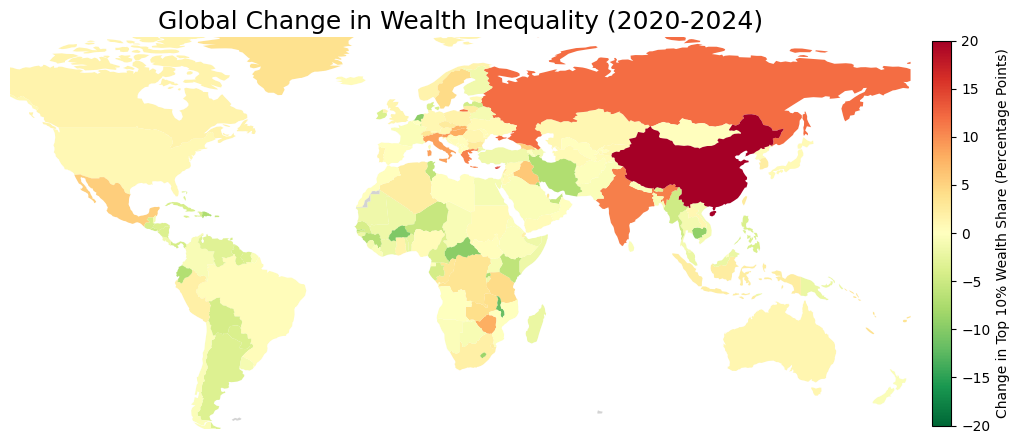

In [82]:
# 4. Plot the visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot missing data in light grey
world.plot(ax=ax, color='#d3d3d3', edgecolor='white')

# Plot the changes (Inequality Heatmap)
world_merged.plot(
    column='top10_change_pp',
    ax=ax,
    legend=True,
    cmap='RdYlGn_r',
    vmin=-20,
    vmax=20,
    missing_kwds={'color': '#d3d3d3'},
    legend_kwds={
        'label': "Change in Top 10% Wealth Share (Percentage Points)",
        'orientation': "vertical",
        'shrink': 0.5,             # control size
        'pad': 0.02                # spacing
    }
)
# Move legend manually to left side (overlapping map)
leg = ax.get_legend()
# Zoom
ax.set_xlim([-140, 180])
ax.set_ylim([-55, 80])
ax.set_title('Global Change in Wealth Inequality (2020-2024)', fontsize=18)
ax.set_axis_off()
plt.show()

In [41]:
# Check which countries in your 'top_change' list didn't make it onto the map
data_only = top_change[~top_change['country'].isin(world['ADMIN'])]
print("Data rows not found on map:")
print(data_only['country'].unique())

Data rows not found on map:
['Malta' 'Sao Tome and Principe' 'Tanzania' 'Monaco'
 'Micronesia, Fed. Sts.' 'Samoa' 'Palau' 'Tuvalu' 'Nauru' 'Tonga'
 'Bermuda' 'French Polynesia' 'Marshall Islands' 'Kiribati' 'DR Congo'
 'Congo Republic' 'Eswatini' 'Singapore' 'Hong Kong' 'Macau'
 'United States' 'Mauritius' 'Serbia' 'Jersey' 'San Marino' 'Guernsey'
 'Gibraltar' 'Isle of Man' 'Andorra' 'Brunei Darussalam' 'Bahrain'
 'Türkiye' 'Timor-Leste' 'St. Kitts and Nevis' "Côte d'Ivoire" 'Bahamas'
 'Liechtenstein' 'Barbados' 'St. Lucia' 'Grenada' 'Curaçao' 'Anguilla'
 'Cayman Islands' 'Montserrat' 'Turks and Caicos Islands' 'Dominica'
 'Aruba' 'British Virgin Islands' 'Antigua and Barbuda' 'Sint Maarten'
 'Bonaire, Saint Eustatius and Saba' 'St. Vincent and the Grenadines'
 'Seychelles' 'Comoros' 'Cabo Verde' 'Maldives' 'not found']


# Conclusion

This analysis of global wealth inequality between 2020 and 2024 reveals a world defined by extreme and structurally embedded concentration of assets. By shifting the focus from income-based summary measures like the Gini coefficient to specific wealth shares (Top 10% and Bottom 50%), this study identified several key patterns that challenge conventional development assumptions.

### 1. Structural Persistence vs. Development Level
The most striking finding is the **lack of a strong relationship between national income level (GNI per capita) and wealth inequality**. Both descriptive statistics and formal statistical testing (ANOVA and regression) demonstrated that wealth concentration is remarkably high across all World Bank income classifications. The Top 10% consistently control approximately 60–63% of national wealth, while the Bottom 50% rarely hold more than 4%. This suggests that wealth exclusion is a global structural feature rather than a symptom of "underdevelopment."

### 2. Divergent Models of Inequality
The analysis identified two distinct mechanisms driving distributional outcomes:
*   **The Elite Concentration Model:** Prevalent in emerging markets and resource-dependent economies (e.g., South Africa, Brazil, Mexico), where historical land ownership patterns and institutional structures lead to extreme Top 10% shares (often exceeding 70%).
*   **The Financialized Debt Model:** Observed in advanced, highly financialized economies (including Nordic countries like Sweden). While these nations may have slightly lower Top 10% shares compared to the extreme emerging markets, they exhibit high Top 10% concentration and frequently negative net wealth for the Bottom 50%. This "inequality from below" is driven by deep credit markets and high household indebtedness (e.g., mortgages and student loans).

### 3. Recent Trends (2020–2024)
While the period of 2020–2024 was marked by significant global shocks, wealth inequality remained largely stable or slightly increased in its structural concentration. The magnitude of change did not differ significantly by region, suggesting that global asset price shocks (such as post-COVID financial market dynamics) affected wealth distributions in a relatively uniform structural manner across different types of economies.

### Final Takeaway
The results of this project suggest that **institutional frameworks, financialization, and asset ownership structures** are far more influential in shaping wealth inequality than national income alone. For policymakers, this implies that economic growth is not a panacea for inequality. Addressing wealth concentration requires targeted interventions in asset distribution, debt restructuring, and the strengthening of institutions that facilitate broad-based asset ownership.